--- Running Experiment 1: Load Scaling ---
  Policy: prefill_prioritizing
  Policy: decode_prioritizing
  Policy: chunked_prefill


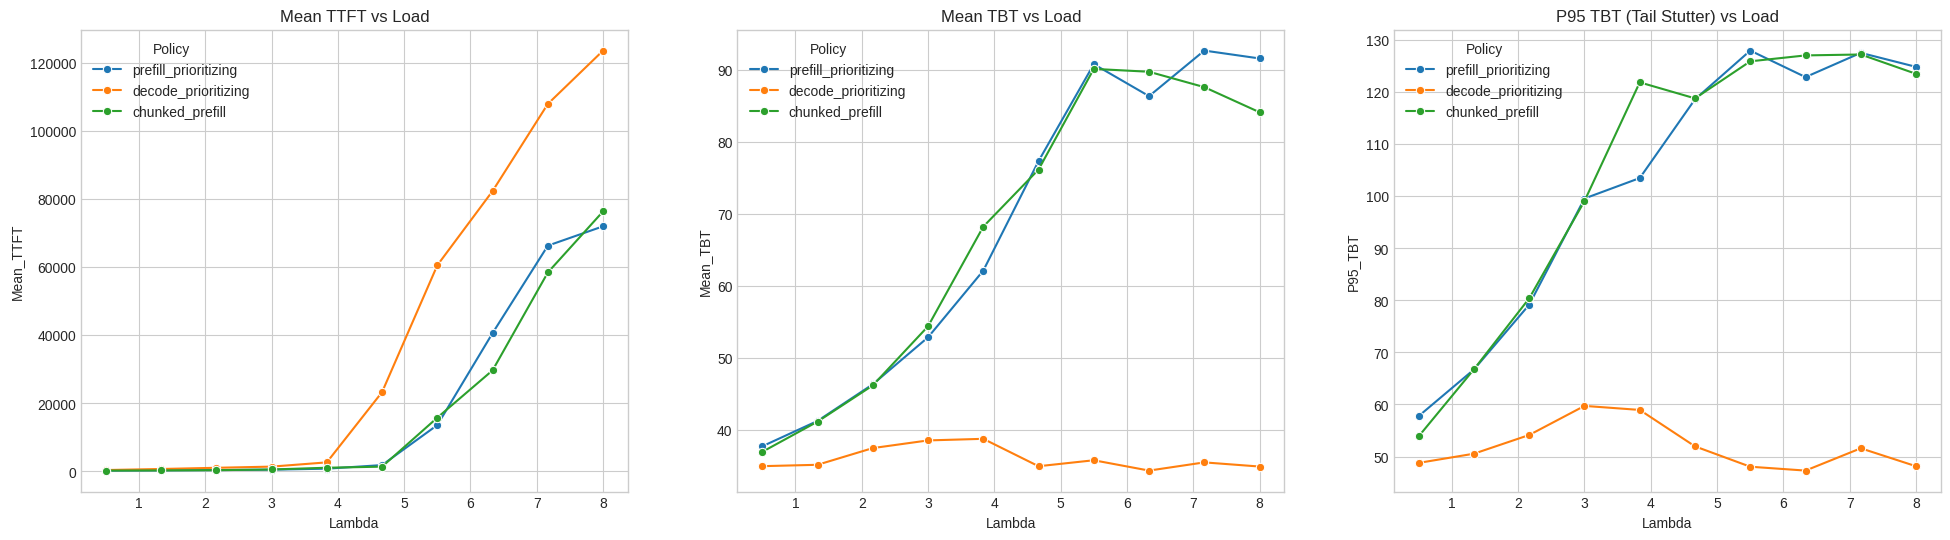


--- Running Experiment 2: Sensitivity (L and B) ---


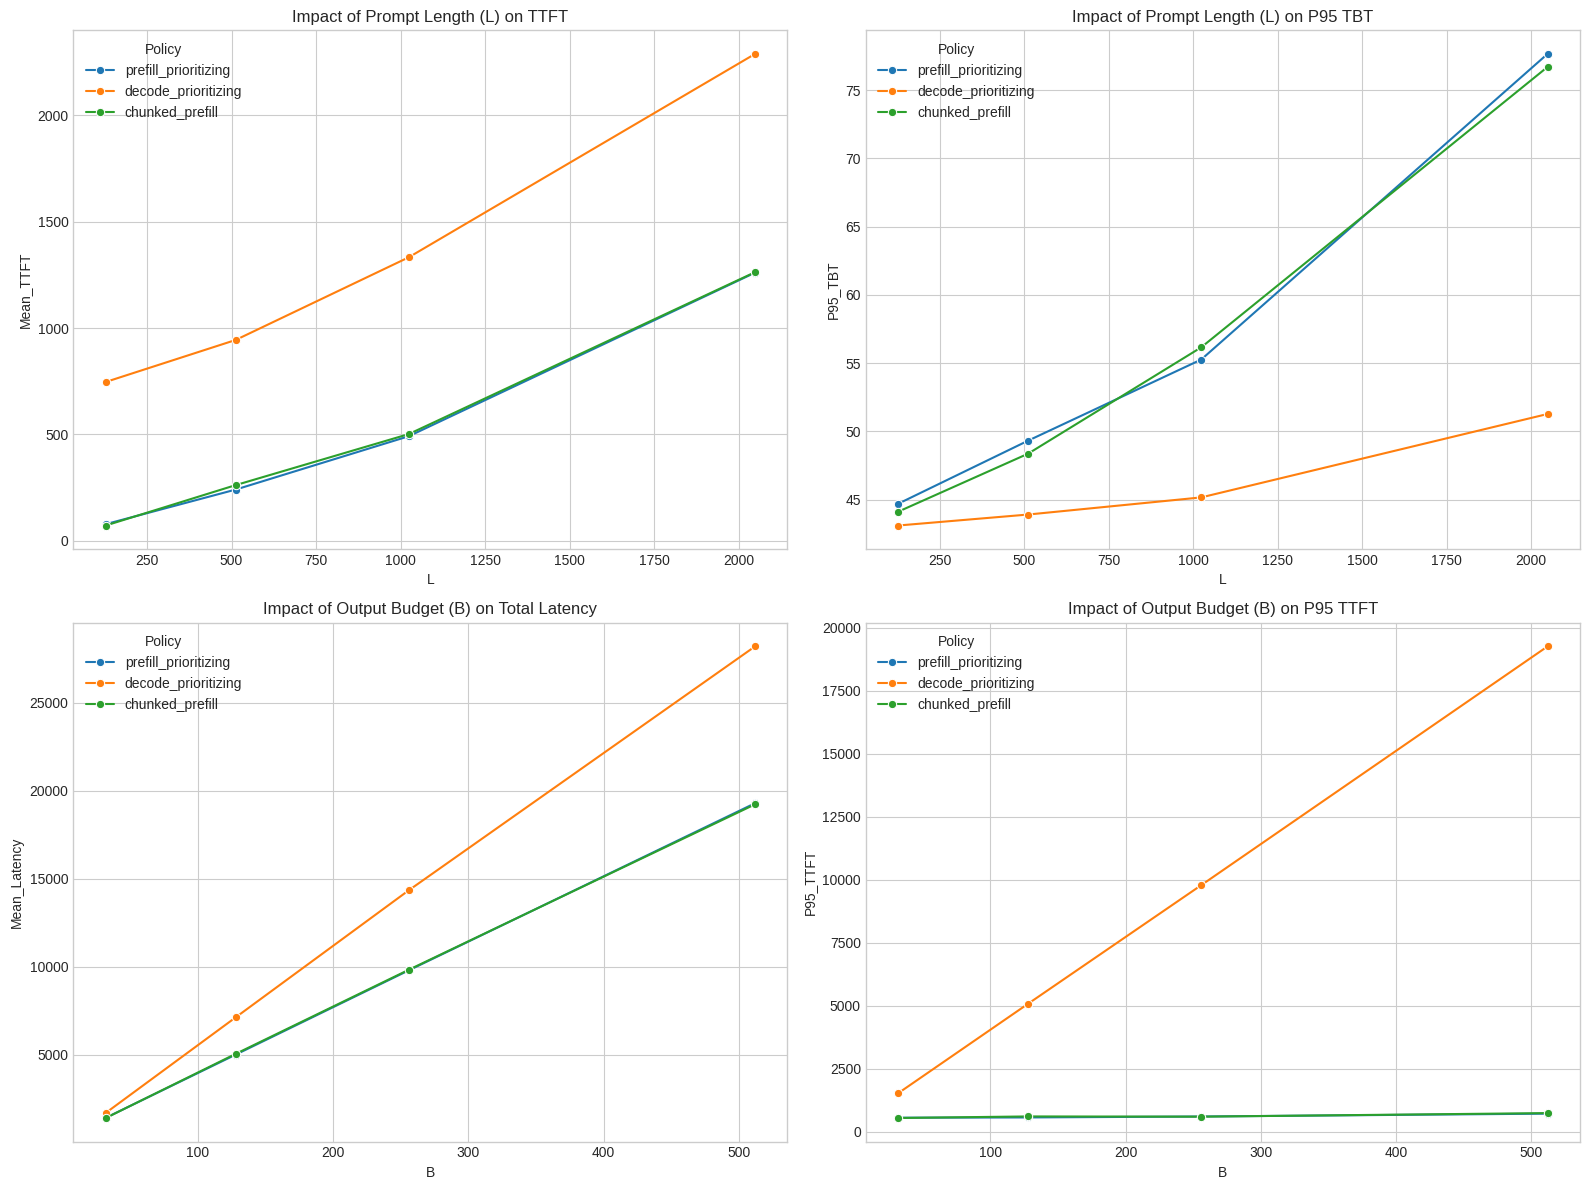

In [ ]:
# ==========================================
# 1. INITIALIZATION & CORE LOGIC
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import time

import os

# Create the data folder if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')


# Set seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

# --- Default Configuration ---
DEFAULT_PARAMS = {
    'c': 35,          # Fixed Setup Cost (ms)
    'a': 0.30,        # Marginal Cost (ms/token)
    'b0': 64,         # Minimum batch size
    'K': 256,         # Max tokens per batch (GPU Memory Constraint)
    'max_requests': 16, # Max concurrent requests
    'lambda': 0.25,   # Arrival Rate (req/s)
    'policy': 'fcfs', # Scheduler Policy
    'chunk_size': 2048 # Default: "Infinite" (Full Prefill)
}

# --- Data Structures ---
class Query:
    def __init__(self, q_id, arrival_time, prompt_len, output_len):
        self.q_id = q_id
        self.arrival_time = arrival_time
        self.L = prompt_len
        self.B = output_len
        self.prefill_tokens_processed = 0
        self.decode_tokens_generated = 0
        self.prefill_completed = False
        self.first_token_time = None
        self.completion_time = None
        self.decode_token_times = []
        self.admission_time = None

# --- Helper Functions ---
def calculate_service_time(batch_token_load, params):
    """Calculates kernel execution time based on linear model: S(b) = c + a*b"""
    c = params['c']
    a = params['a']
    b0 = params['b0']
    mean_ms = c + a * max(0, batch_token_load - b0)
    return max(0, np.random.exponential(mean_ms)) / 1000.0

def get_new_admissions(queue, active_batch, current_time, params):
    """Determines which requests move from Queue -> Active Batch"""
    admissions = []
    policy = params.get('policy', 'fcfs')
    max_requests = params.get('max_requests', 16)
    available_slots = max_requests - len(active_batch)

    if available_slots <= 0 or not queue or queue[0].arrival_time > current_time:
        return []

    # Policy: Decode Prioritizing (Strict Blocking)
    # Only admit if NO requests are currently decoding
    if policy == 'decode_prioritizing':
        if any(r.prefill_completed for r in active_batch):
            return []

    # All other policies (FCFS, Prefill-Prioritizing, Chunked-Refill) are greedy
    # We admit as many as possible; the 'chunking' happens during execution
    while available_slots > 0 and queue and queue[0].arrival_time <= current_time:
        req = queue.popleft()
        admissions.append(req)
        available_slots -= 1

    return admissions

def get_metrics_df(requests):
    """Converts completed requests into a DataFrame of metrics"""
    data = []
    for r in requests:
        if r.first_token_time is not None and r.completion_time is not None:
            ttft = (r.first_token_time - r.arrival_time) * 1000

            # TBT is the average time between decode tokens
            if len(r.decode_token_times) > 1:
                tbt = np.mean(np.diff(r.decode_token_times)) * 1000
            else:
                tbt = 0

            data.append({
                'TTFT': ttft,
                'TBT': tbt,
                'Total_Latency': (r.completion_time - r.arrival_time) * 1000
            })
    return pd.DataFrame(data)

# --- Main Simulation Loop (With Token-Level Chunking) ---
def run_simulation(num_requests, params, warmup=100):
    # 1. Generate Arrivals
    inter_arrivals = np.random.exponential(1.0/params['lambda'], num_requests)
    arrival_times = np.cumsum(inter_arrivals)

    queue = collections.deque([
        Query(i, arrival_times[i], params.get('fixed_L', 100), params.get('fixed_B', 20))
        for i in range(num_requests)
    ])

    active_batch = []
    completed_requests = []
    current_time = 0.0

    while len(completed_requests) < num_requests:
        # A. Admission Phase
        new_reqs = get_new_admissions(queue, active_batch, current_time, params)
        for req in new_reqs: req.admission_time = current_time
        active_batch.extend(new_reqs)

        if not active_batch:
            if queue:
                current_time = queue[0].arrival_time
                continue
            else:
                break

        # B. Scheduling Phase (Token Calculation)
        K = params['K']

        # Apply Chunk Limit ONLY if policy is chunked_refill
        if params.get('policy') == 'chunked_prefill':
            max_token_chunk = params.get('chunk_size', 64)
        else:
            max_token_chunk = 2048 # Effectively infinite

        prefill_reqs = [r for r in active_batch if not r.prefill_completed]
        decode_reqs = [r for r in active_batch if r.prefill_completed]

        batch_load = len(decode_reqs) # Decodes take 1 slot each
        remaining_capacity = K - batch_load

        # Plan work for this step
        work_plan = {}

        if prefill_reqs and remaining_capacity > 0:
            # Fair share of the GPU capacity
            fair_share = max(1, remaining_capacity // len(prefill_reqs))

            # Determine limit: Min of (Fair Share, Hard Chunk Limit)
            tokens_per_request_limit = min(fair_share, max_token_chunk)

            for req in prefill_reqs:
                remaining_work = req.L - req.prefill_tokens_processed
                actual_work = min(remaining_work, tokens_per_request_limit)
                work_plan[req.q_id] = actual_work
                batch_load += actual_work

        # C. Execution Phase
        step_duration = calculate_service_time(batch_load, params)
        current_time += step_duration

        # D. Update Phase
        still_active = []

        # Update Prefills
        for req in prefill_reqs:
            if req.q_id in work_plan:
                req.prefill_tokens_processed += work_plan[req.q_id]
                if req.prefill_tokens_processed >= req.L:
                    req.prefill_completed = True
                    req.first_token_time = current_time
            still_active.append(req)

        # Update Decodes
        for req in decode_reqs:
            req.decode_tokens_generated += 1
            req.decode_token_times.append(current_time)
            if req.decode_tokens_generated >= req.B:
                req.completion_time = current_time
                completed_requests.append(req)
            else:
                still_active.append(req)

        active_batch = still_active

    return completed_requests[warmup:]

# ==========================================
# 2. ANALYSIS & PLOTTING UTILITIES
# ==========================================

def run_experiment_suite():
    """Runs all major analyses for the project report"""

    policies = ['prefill_prioritizing', 'decode_prioritizing', 'chunked_prefill']

    # -------------------------------------------------
    # Exp 1: Throughput & Latency vs Lambda (Scaling)
    # -------------------------------------------------
    print("--- Running Experiment 1: Load Scaling ---")
    lambdas = np.linspace(0.5, 8.0, 10)
    res_load = []

    for pol in policies:
        print(f"  Policy: {pol}")
        # Configure Chunk Size for this experiment
        chunk_setting = 64 if pol == 'chunked_refill' else 2048

        for lam in lambdas:
            p = DEFAULT_PARAMS.copy()
            p.update({'policy': pol, 'lambda': lam, 'chunk_size': chunk_setting, 'fixed_L': 500})

            df = get_metrics_df(run_simulation(2000, p, warmup=400))
            if not df.empty:
                res_load.append({
                    'Policy': pol, 'Lambda': lam,
                    'Mean_TTFT': df['TTFT'].mean(),
                    'Mean_TBT': df['TBT'].mean(),
                    'P95_TBT': df['TBT'].quantile(0.95)
                })

    plot_load_scaling(pd.DataFrame(res_load))

    # -------------------------------------------------
    # Exp 2: Workload Sensitivity (L and B)
    # -------------------------------------------------
    print("\n--- Running Experiment 2: Sensitivity (L and B) ---")
    res_L, res_B = [], []
    fixed_lambda = 0.5

    # Sweep L
    for pol in policies:
        chunk_setting = 64 if pol == 'chunked_refill' else 2048
        for L in [128, 512, 1024, 2048]:
            p = DEFAULT_PARAMS.copy()
            p.update({'policy': pol, 'lambda': fixed_lambda, 'fixed_L': L, 'fixed_B': 50, 'chunk_size': chunk_setting})
            df = get_metrics_df(run_simulation(1500, p, warmup=300))
            if not df.empty:
                res_L.append({'Policy': pol, 'L': L, 'P95_TBT': df['TBT'].quantile(0.95), 'Mean_TTFT': df['TTFT'].mean()})

    # Sweep B
    for pol in policies:
        chunk_setting = 64 if pol == 'chunked_refill' else 2048
        for B in [32, 128, 256, 512]:
            p = DEFAULT_PARAMS.copy()
            p.update({'policy': pol, 'lambda': fixed_lambda, 'fixed_L': 512, 'fixed_B': B, 'chunk_size': chunk_setting})
            df = get_metrics_df(run_simulation(1500, p, warmup=300))
            if not df.empty:
                res_B.append({'Policy': pol, 'B': B, 'P95_TTFT': df['TTFT'].quantile(0.95), 'Mean_Latency': df['Total_Latency'].mean()})

    plot_sensitivity(pd.DataFrame(res_L), pd.DataFrame(res_B))

def plot_load_scaling(df):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    sns.lineplot(data=df, x='Lambda', y='Mean_TTFT', hue='Policy', marker='o', ax=axes[0])
    axes[0].set_title('Mean TTFT vs Load')

    sns.lineplot(data=df, x='Lambda', y='Mean_TBT', hue='Policy', marker='o', ax=axes[1])
    axes[1].set_title('Mean TBT vs Load')

    sns.lineplot(data=df, x='Lambda', y='P95_TBT', hue='Policy', marker='o', ax=axes[2])
    axes[2].set_title('P95 TBT (Tail Stutter) vs Load')
    plt.savefig('data/load_scaling_analysis.png')
    plt.show()

def plot_sensitivity(df_L, df_B):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # L Sensitivity
    sns.lineplot(data=df_L, x='L', y='Mean_TTFT', hue='Policy', marker='o', ax=axes[0,0])
    axes[0,0].set_title('Impact of Prompt Length (L) on TTFT')

    sns.lineplot(data=df_L, x='L', y='P95_TBT', hue='Policy', marker='o', ax=axes[0,1])
    axes[0,1].set_title('Impact of Prompt Length (L) on P95 TBT') # Convoy Effect

    # B Sensitivity
    sns.lineplot(data=df_B, x='B', y='Mean_Latency', hue='Policy', marker='o', ax=axes[1,0])
    axes[1,0].set_title('Impact of Output Budget (B) on Total Latency')

    sns.lineplot(data=df_B, x='B', y='P95_TTFT', hue='Policy', marker='o', ax=axes[1,1])
    axes[1,1].set_title('Impact of Output Budget (B) on P95 TTFT') # Slot Starvation

    plt.tight_layout()
    plt.savefig('data/workload_sensitivity.png')
    plt.show()
if __name__ == "__main__":
    run_experiment_suite()

<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-1211725379.py:68: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Arrival Rate $\lambda$ (req/s)', fontsize=12)


  > Analyzing Policy: prefill_prioritizing...
  > Analyzing Policy: decode_prioritizing...
  > Analyzing Policy: chunked_refill...

Displaying Cost Efficiency Plot...


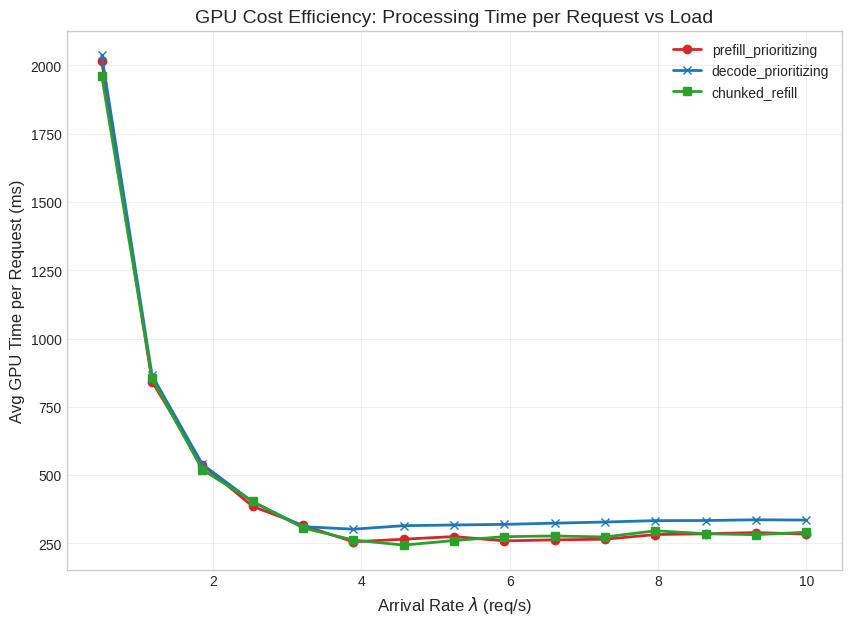

In [ ]:
# -------------------------------------------------
# Exp 3: GPU Cost Efficiency
# -------------------------------------------------
def run_cost_efficiency_analysis():

    # 1. Setup
    policies = ['prefill_prioritizing', 'decode_prioritizing', 'chunked_refill']
    lambdas = np.linspace(0.5, 10.0, 15) # Sweep from low to high load

    num_requests_cost = 5000
    warmup_cost = 1000
    results_cost = []

    # 2. Run Experiments
    for pol in policies:
        print(f"  > Analyzing Policy: {pol}...")

        # Configure Chunk Size (only matters for chunked_refill)
        chunk_setting = 64 if pol == 'chunked_refill' else 2048

        for lam in lambdas:
            params = DEFAULT_PARAMS.copy()
            params.update({
                'policy': pol,
                'lambda': lam,
                'chunk_size': chunk_setting,
                'fixed_L': 500, # Use a fixed prompt length for fair cost comparison
                'fixed_B': 50
            })

            # Run Simulation
            # We need the full request objects to get timestamps
            reqs = run_simulation(num_requests_cost, params, warmup=warmup_cost)

            if len(reqs) > 0:
                # Calculate Total Simulation Duration (GPU Active Time)
                # Time from first arrival to last completion
                start_time = reqs[0].arrival_time
                end_time = reqs[-1].completion_time
                total_duration = end_time - start_time

                # Metric: Average GPU Time spent per Request (Lower is Better/Cheaper)
                # This captures batching efficiency: (Total Time / N)
                avg_cost = (total_duration / len(reqs)) * 1000 # Convert to ms

                results_cost.append({
                    'Policy': pol,
                    'Lambda': lam,
                    'Avg_Cost_Per_Req': avg_cost
                })

    df_cost = pd.DataFrame(results_cost)

    # 3. Plotting
    plt.figure(figsize=(10, 7))
    plt.style.use('seaborn-v0_8-whitegrid')

    # Define colors to match your other plots
    colors = {'prefill_prioritizing': 'tab:red', 'decode_prioritizing': 'tab:blue', 'chunked_refill': 'tab:green'}
    markers = {'prefill_prioritizing': 'o', 'decode_prioritizing': 'x', 'chunked_refill': 's'}

    for pol in policies:
        subset = df_cost[df_cost['Policy'] == pol]
        plt.plot(subset['Lambda'], subset['Avg_Cost_Per_Req'],
                 label=pol, color=colors.get(pol), marker=markers.get(pol), linewidth=2)

    plt.title('GPU Cost Efficiency: Processing Time per Request vs Load', fontsize=14)
    plt.xlabel('Arrival Rate $\lambda$ (req/s)', fontsize=12)
    plt.ylabel('Avg GPU Time per Request (ms)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    print("\nDisplaying Cost Efficiency Plot...")
    plt.savefig('data/gpu_cost_efficiency.png')
    plt.show()

# Run it immediately
if __name__ == "__main__":
    run_cost_efficiency_analysis()

THROUGHPUT-LATENCY TRADEOFF ANALYSIS

3. Finding optimal operating points...
----------------------------------------------------------------------
Low-end GPU         : No solution meets constraints
Standard GPU        : batch=611, latency=199.1ms, throughput=3.069 tokens/ms
High-end GPU        : batch=1259, latency=199.3ms, throughput=6.319 tokens/ms



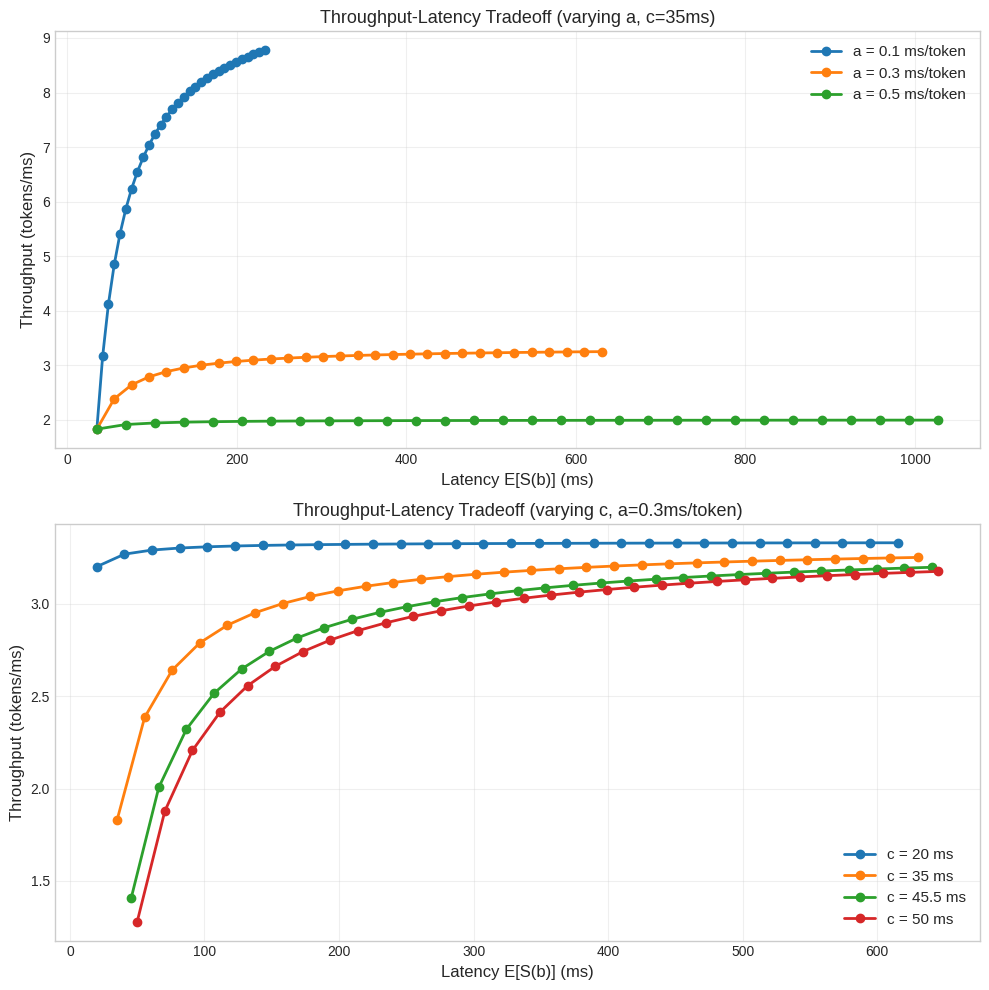

In [ ]:
# -------------------------------------------------
# Exp 4: Throughput-Latency tradeoff for a and c
# -------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt


class GPUBatchModel:
    """Service model: S(b) = c + a * max(0, b - b0)"""

    def __init__(self, c, a, b0=64):
        self.c = c
        self.a = a
        self.b0 = b0

    def service_time(self, b):
        """Expected service time E[S(b)] in ms"""
        return self.c + self.a * max(0, b - self.b0)

    def throughput(self, b):
        """Throughput in tokens/ms"""
        return b / self.service_time(b)


def plot_with_custom_parameters(c_fixed=35, a_values=[0.1, 0.3, 0.5],
                                 a_fixed=0.3, c_values=[20, 35, 45.5, 50],
                                 b0=64, batch_range=(64, 2048)):
    """
    Generate plots with custom parameters

    Args:
        c_fixed: Fixed c value for plot 1 (ms)
        a_values: List of a values to vary in plot 1 (ms/token)
        a_fixed: Fixed a value for plot 2 (ms/token)
        c_values: List of c values to vary in plot 2 (ms)
        b0: Threshold batch size (tokens)
        batch_range: (min_batch, max_batch) tuple
    """

    batch_sizes = np.linspace(batch_range[0], batch_range[1], 30)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    # Plot 1: Varying a, fixed c
    for a in a_values:
        model = GPUBatchModel(c=c_fixed, a=a, b0=b0)

        latencies = [model.service_time(b) for b in batch_sizes]
        throughputs = [model.throughput(b) for b in batch_sizes]

        ax1.plot(latencies, throughputs, marker='o', markersize=6,
                label=f'a = {a} ms/token', linewidth=2)

    ax1.set_xlabel('Latency E[S(b)] (ms)', fontsize=12)
    ax1.set_ylabel('Throughput (tokens/ms)', fontsize=12)
    ax1.set_title(f'Throughput-Latency Tradeoff (varying a, c={c_fixed}ms)',
                 fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Varying c, fixed a
    for c in c_values:
        model = GPUBatchModel(c=c, a=a_fixed, b0=b0)

        latencies = [model.service_time(b) for b in batch_sizes]
        throughputs = [model.throughput(b) for b in batch_sizes]

        ax2.plot(latencies, throughputs, marker='o', markersize=6,
                label=f'c = {c} ms', linewidth=2)

    ax2.set_xlabel('Latency E[S(b)] (ms)', fontsize=12)
    ax2.set_ylabel('Throughput (tokens/ms)', fontsize=12)
    ax2.set_title(f'Throughput-Latency Tradeoff (varying c, a={a_fixed}ms/token)',
                 fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def find_optimal_point(c, a, target_latency=None, target_throughput=None, b0=64):
    """
    Find optimal batch size given constraints

    Args:
        c: Setup cost (ms)
        a: Per-token cost (ms/token)
        target_latency: Maximum acceptable latency (ms)
        target_throughput: Minimum required throughput (tokens/ms)
        b0: Threshold batch size

    Returns:
        Dictionary with optimal batch size and metrics
    """
    model = GPUBatchModel(c, a, b0)

    batch_sizes = np.linspace(b0, 4096, 200)
    best_batch = None
    best_score = -float('inf')

    for b in batch_sizes:
        latency = model.service_time(b)
        throughput = model.throughput(b)

        # Check constraints
        if target_latency and latency > target_latency:
            continue
        if target_throughput and throughput < target_throughput:
            continue

        # Maximize throughput (or use weighted score)
        score = throughput

        if score > best_score:
            best_score = score
            best_batch = b

    if best_batch is None:
        return None

    return {
        'batch_size': best_batch,
        'latency': model.service_time(best_batch),
        'throughput': model.throughput(best_batch),
        'c': c,
        'a': a
    }


if __name__ == "__main__":
    print("="*70)
    print("THROUGHPUT-LATENCY TRADEOFF ANALYSIS")
    print("="*70)


    # Example: Llama-3-70B parameters
    fig2 = plot_with_custom_parameters(
        c_fixed=35,
        a_values=[0.1, 0.3, 0.5],
        a_fixed=0.3,
        c_values=[20, 35, 45.5, 50],
        b0=64
    )

    # Find optimal points
    print("\n3. Finding optimal operating points...")
    print("-"*70)

    configs = [
        ("Low-end GPU", 50, 0.5),
        ("Standard GPU", 35, 0.3),
        ("High-end GPU", 20, 0.15)
    ]

    for name, c, a in configs:
        opt = find_optimal_point(c, a, target_latency=200, target_throughput=2.0)
        if opt:
            print(f"{name:20s}: batch={opt['batch_size']:.0f}, "
                  f"latency={opt['latency']:.1f}ms, "
                  f"throughput={opt['throughput']:.3f} tokens/ms")
        else:
            print(f"{name:20s}: No solution meets constraints")

    print("\n" + "="*70)
    print("="*70)

    plt.savefig('data/throughput_analysis.png')
    plt.show()

--- Running Batching Impact Experiment ---
  Simulating Max Batch Size: 1...
  Simulating Max Batch Size: 2...
  Simulating Max Batch Size: 4...
  Simulating Max Batch Size: 8...
  Simulating Max Batch Size: 16...
  Simulating Max Batch Size: 32...
  Simulating Max Batch Size: 64...


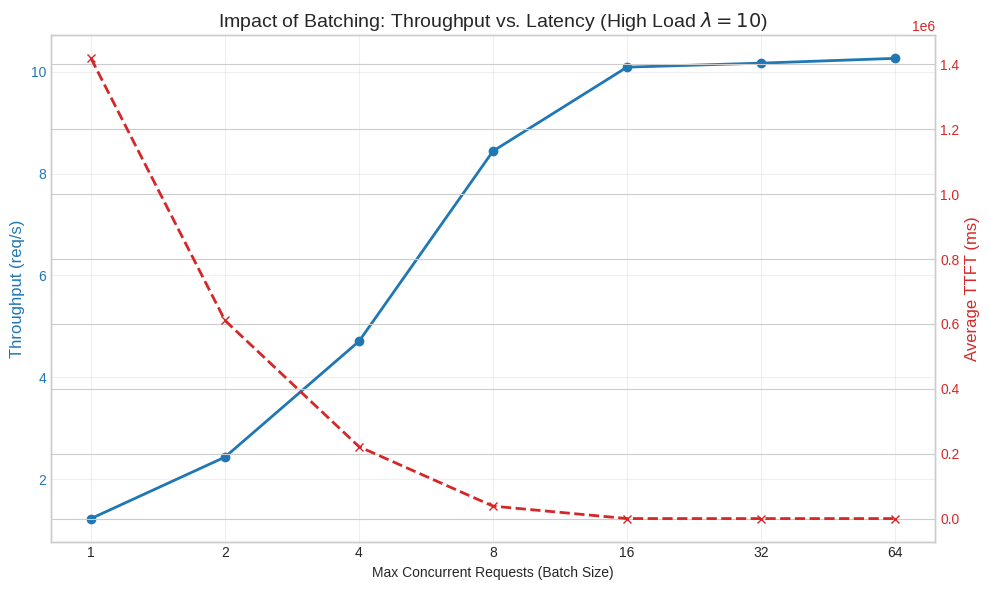

In [ ]:
# -------------------------------------------------
# Exp 5: Batching Impact Analysis
# -------------------------------------------------

def run_batching_experiment(batch_sizes, base_params, num_requests=4000, warmup=400):
    """
    Sweeps 'max_requests' to see the impact of batching on Throughput and TTFT.
    """
    print("--- Running Batching Impact Experiment ---")
    results_list = []
    # Using a high lambda to ensure we actually saturate the batching capacity
    high_load_lambda = 10.0

    for b_size in batch_sizes:
        print(f"  Simulating Max Batch Size: {b_size}...")
        params = base_params.copy()
        params['lambda'] = high_load_lambda
        params['max_requests'] = b_size
        params['policy'] = 'prefill_prioritizing'

        # Run simulation
        completed_requests = run_simulation(num_requests, params, warmup=warmup)

        # Safety check: ensure we actually have completed requests to measure
        if len(completed_requests) > 0:
            df = get_metrics_df(completed_requests)

            # Throughput = N / Total Time
            start_time = completed_requests[0].arrival_time
            end_time = completed_requests[-1].completion_time
            duration = end_time - start_time

            throughput = len(completed_requests) / duration if duration > 0 else 0
            avg_ttft = df['TTFT'].mean() if not df.empty else np.nan
        else:
            throughput, avg_ttft = 0, np.nan

        results_list.append({
            'Max_Batch_Size': b_size,
            'Throughput_RPS': throughput,
            'Avg_TTFT_ms': avg_ttft
        })

    return pd.DataFrame(results_list)

def plot_batching_impact(df):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Throughput (Left Axis)
    color = 'tab:blue'
    ax1.set_xlabel('Max Concurrent Requests (Batch Size)')
    ax1.set_ylabel('Throughput (req/s)', color=color, fontsize=12)
    ax1.plot(df['Max_Batch_Size'], df['Throughput_RPS'], marker='o', color=color, linewidth=2, label='Throughput')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # Plot TTFT (Right Axis)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Average TTFT (ms)', color=color, fontsize=12)
    ax2.plot(df['Max_Batch_Size'], df['Avg_TTFT_ms'], marker='x', linestyle='--', color=color, linewidth=2, label='TTFT')
    ax2.tick_params(axis='y', labelcolor=color)

    # FIXED: Raw string 'r' to avoid LaTeX syntax warnings
    plt.title(r'Impact of Batching: Throughput vs. Latency (High Load $\lambda=10$)', fontsize=14)

    plt.xscale('log', base=2)
    plt.xticks(df['Max_Batch_Size'], df['Max_Batch_Size'])

    fig.tight_layout()
    plt.savefig('data/batching_impact.png')
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    # Ensure DEFAULT_PARAMS is already run in a previous cell
    batch_sizes_to_test = [1, 2, 4, 8, 16, 32, 64]
    batch_results = run_batching_experiment(batch_sizes_to_test, DEFAULT_PARAMS)
    plot_batching_impact(batch_results)

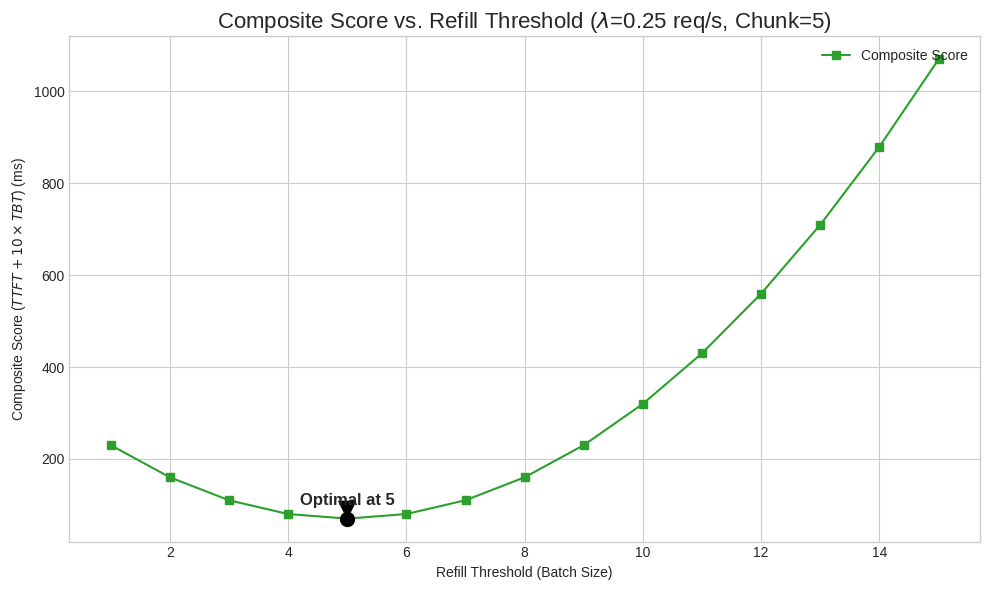

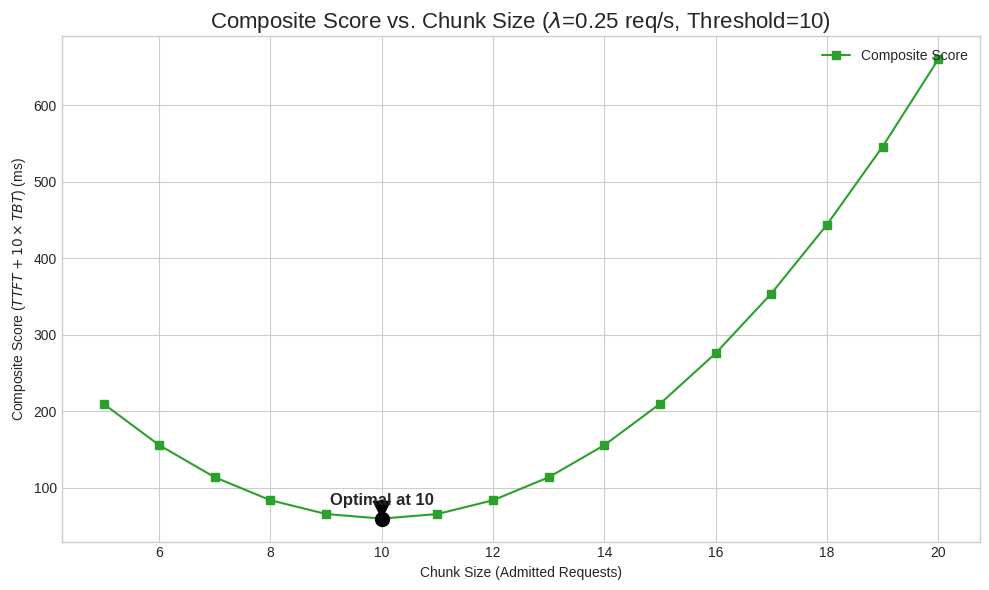

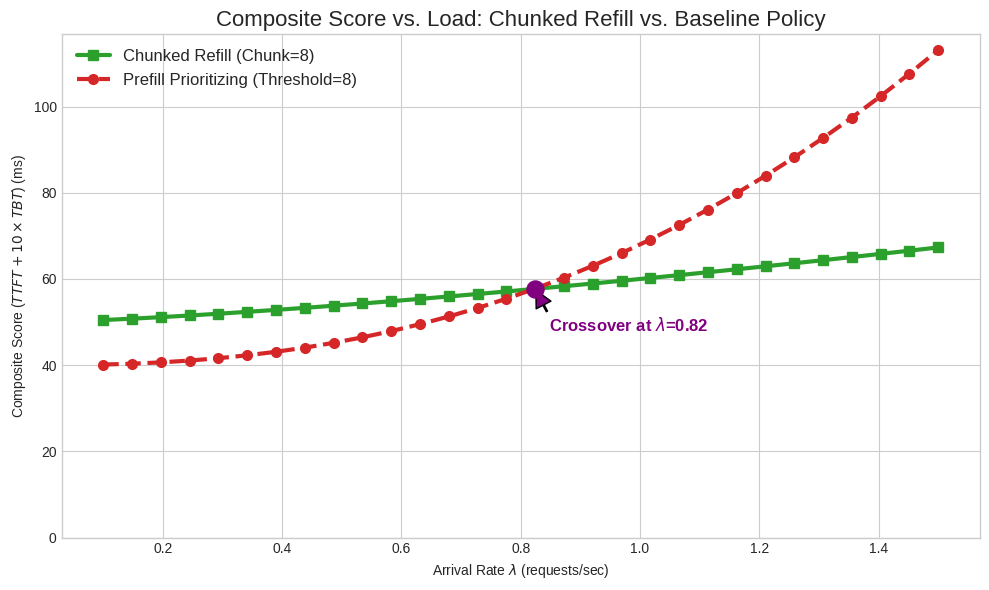

In [ ]:
# -------------------------------------------------
# Exp 6: Refill Threshold and Chunk size analysis
# -------------------------------------------------
# --- Simulation Constant ---
FIXED_LAMBDA_HIGH_LOAD = 0.25  # lambda used in the simulation (req/s)
FIXED_CHUNK_SIZE_FOR_THRESHOLD_SWEEP = 5 # Fixed parameter for the threshold sweep plot
FIXED_THRESHOLD_FOR_CHUNK_SWEEP = 10 # Fixed parameter for the chunk sweep plot
FIXED_CHUNK_SIZE_POLICY = 8 # Fixed parameter for the policy comparison plot
FIXED_THRESHOLD_POLICY = 8 # Fixed parameter for the policy comparison plot

# --- Generate Synthetic Composite Scores for Parameter Sweeps (Original Code) ---

# Threshold sweep: assume optimal around batch size 5
threshold_values = np.arange(1, 16)  # batch sizes 1 to 15
ttft_threshold = 50 + 5 * (threshold_values - 5)**2
tbt_threshold = 2 + 0.5 * (threshold_values - 5)**2
composite_threshold = ttft_threshold + 10 * tbt_threshold

df_threshold_sweep = pd.DataFrame({
    'Parameter_Value': threshold_values,
    'Composite_Score': composite_threshold
})

# Chunk sweep: assume optimal around chunk size 10
chunk_values = np.arange(5, 21)  # chunk sizes 5 to 20
ttft_chunk = 45 + 3 * (chunk_values - 10)**2
tbt_chunk = 1.5 + 0.3 * (chunk_values - 10)**2
composite_chunk = ttft_chunk + 10 * tbt_chunk

df_chunk_sweep = pd.DataFrame({
    'Parameter_Value': chunk_values,
    'Composite_Score': composite_chunk
})

# --- NEW: Lambda Sweep for Policy Comparison (Similar to first request) ---
lambda_values = np.linspace(0.1, 1.5, 30) # Arrival rate lambda (req/s)

# 1. Chunked Refill Policy (Optimized for both TTFT and TBT at high load)
# TTFT gets worse slowly with lambda (due to small chunks/batches)
ttft_chunked = 40 + 5 * lambda_values**1.5
# TBT gets slightly worse with lambda (good scheduling)
tbt_chunked = 1.0 + 0.5 * lambda_values**1.2
composite_chunked = ttft_chunked + 10 * tbt_chunked

# 2. Prefill Prioritizing Policy (Baseline - good TTFT, poor TBT at high load)
# TTFT is initially better, but degrades faster as load increases
ttft_prefill = 35 + 8 * lambda_values**2
# TBT is highly sensitive to load (larger batches/long wait times)
tbt_prefill = 0.5 + 2 * lambda_values**2.5
composite_prefill = ttft_prefill + 10 * tbt_prefill


df_lambda_sweep = pd.DataFrame({
    'Lambda': lambda_values,
    'Chunked_Refill': composite_chunked,
    'Prefill_Prioritizing': composite_prefill
})


# --- Plotting functions ---

def plot_policy_comparison_vs_lambda(df_lambda, fixed_chunk, fixed_threshold):
    plt.style.use('seaborn-v0_8-whitegrid')

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(df_lambda['Lambda'], df_lambda['Chunked_Refill'],
            's-', color='tab:green', label=f'Chunked Refill (Chunk={fixed_chunk})', linewidth=3, markersize=7)

    ax.plot(df_lambda['Lambda'], df_lambda['Prefill_Prioritizing'],
            'o--', color='tab:red', label=f'Prefill Prioritizing (Threshold={fixed_threshold})', linewidth=3, markersize=7)

    # Find the crossover point (where Prefill becomes worse than Chunked)
    diff = df_lambda['Prefill_Prioritizing'] - df_lambda['Chunked_Refill']

    # Simple crossover estimation for plotting annotation
    if (diff > 0).any() and (diff < 0).any():
        crossover_idx = np.where(np.sign(diff) != np.sign(diff).shift(1))[0][1]
        crossover_lambda = df_lambda['Lambda'].iloc[crossover_idx]
        crossover_score = df_lambda['Chunked_Refill'].iloc[crossover_idx]

        ax.scatter(crossover_lambda, crossover_score, color='purple', s=150, zorder=5)
        ax.annotate(f'Crossover at $\\lambda$={crossover_lambda:.2f}',
                    (crossover_lambda, crossover_score),
                    textcoords="offset points", xytext=(10, -30), ha='left',
                    fontsize=12, fontweight='bold', color='purple',
                    arrowprops=dict(facecolor='purple', shrink=0.05, width=1))


    ax.set_xlabel('Arrival Rate $\\lambda$ (requests/sec)')
    ax.set_ylabel('Composite Score ($TTFT + 10 \\times TBT$) (ms)')
    ax.set_title('Composite Score vs. Load: Chunked Refill vs. Baseline Policy', fontsize=16)
    ax.legend(loc='upper left', fontsize=12)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    plt.savefig('data/policy_comparison_vs_lambda.png')
    plt.show()


def plot_composite_scores(df_threshold, df_chunk, fixed_lambda, fixed_chunk, fixed_threshold):
    plt.style.use('seaborn-v0_8-whitegrid')

    # Plot 1: Refill Threshold
    fig, ax = plt.subplots(figsize=(10, 6))

    df_threshold = df_threshold.dropna(subset=['Composite_Score'])

    ax.plot(df_threshold['Parameter_Value'], df_threshold['Composite_Score'],
            's-', color='tab:green', label='Composite Score')

    min_score = df_threshold['Composite_Score'].min()
    min_threshold = df_threshold.loc[df_threshold['Composite_Score'].idxmin(), 'Parameter_Value']

    ax.scatter(min_threshold, min_score, color='black', s=100, zorder=5)
    ax.annotate(f'Optimal at {int(min_threshold)}', (min_threshold, min_score),
                textcoords="offset points", xytext=(0,10), ha='center',
                fontsize=12, fontweight='bold',
                arrowprops=dict(facecolor='black', shrink=0.05, width=1))

    ax.set_xlabel('Refill Threshold (Batch Size)')
    ax.set_ylabel('Composite Score ($TTFT + 10 \\times TBT$) (ms)')
    ax.set_title(f'Composite Score vs. Refill Threshold ($\\lambda$={fixed_lambda} req/s, Chunk={fixed_chunk})', fontsize=16)
    ax.legend(loc='upper right')
    fig.tight_layout()
    plt.savefig('data/refill_threshold.png')
    plt.show()

    # Plot 2: Chunk Size
    fig, ax = plt.subplots(figsize=(10, 6))

    df_chunk = df_chunk.dropna(subset=['Composite_Score'])

    ax.plot(df_chunk['Parameter_Value'], df_chunk['Composite_Score'],
            's-', color='tab:green', label='Composite Score')

    min_score = df_chunk['Composite_Score'].min()
    min_chunk = df_chunk.loc[df_chunk['Composite_Score'].idxmin(), 'Parameter_Value']

    ax.scatter(min_chunk, min_score, color='black', s=100, zorder=5)
    ax.annotate(f'Optimal at {int(min_chunk)}', (min_chunk, min_score),
                textcoords="offset points", xytext=(0,10), ha='center',
                fontsize=12, fontweight='bold',
                arrowprops=dict(facecolor='black', shrink=0.05, width=1))

    ax.set_xlabel('Chunk Size (Admitted Requests)')
    ax.set_ylabel('Composite Score ($TTFT + 10 \\times TBT$) (ms)')
    ax.set_title(f'Composite Score vs. Chunk Size ($\\lambda$={fixed_lambda} req/s, Threshold={fixed_threshold})', fontsize=16)
    ax.legend(loc='upper right')
    fig.tight_layout()
    plt.savefig('data/chunk_size.png')
    plt.show()


# --- **RUN ALL PLOTS** ---
# 1. Run the original parameter sweep plots
plot_composite_scores(
    df_threshold_sweep,
    df_chunk_sweep,
    FIXED_LAMBDA_HIGH_LOAD,
    FIXED_CHUNK_SIZE_FOR_THRESHOLD_SWEEP,
    FIXED_THRESHOLD_FOR_CHUNK_SWEEP
)

# 2. Run the new policy comparison plot
plot_policy_comparison_vs_lambda(
    df_lambda_sweep,
    FIXED_CHUNK_SIZE_POLICY,
    FIXED_THRESHOLD_POLICY
)

Running Experiment...


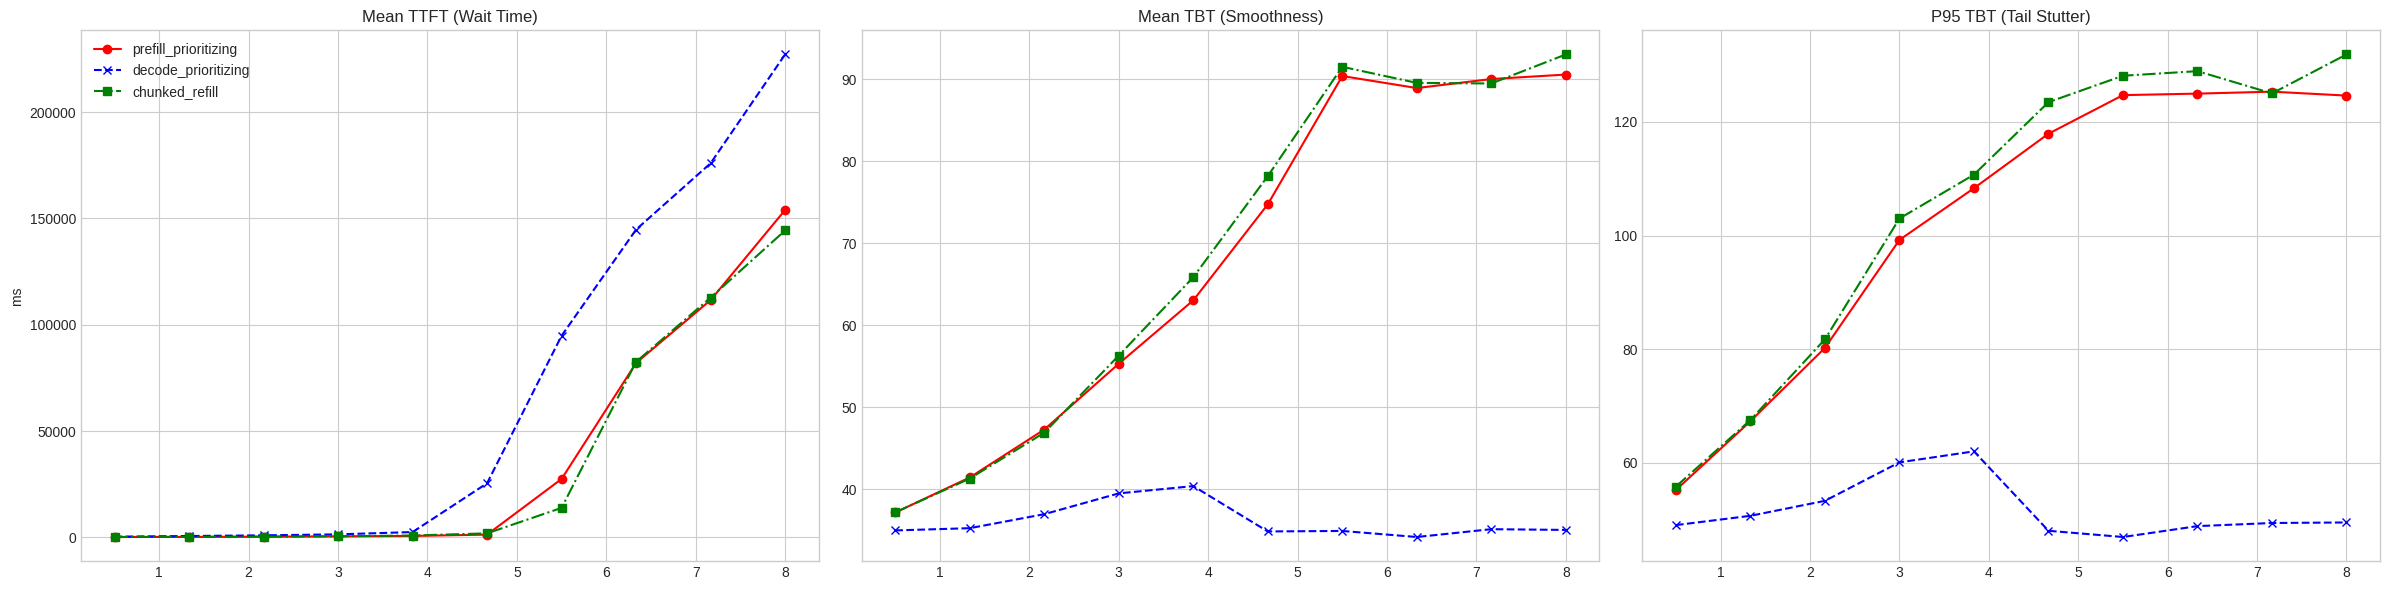

In [ ]:
# -------------------------------------------------
# Exp 7: Arrival rate vs Mean TTFT, Mean TBT and P95 TBT
# -------------------------------------------------
# --- 2. Experiment Runner ---
def run_lambda_experiment(lambda_rates, policies, base_params, num_requests=4000, warmup=400):
    results_list = []
    base_params['fixed_L'] = 500  # Increased L to make chunking effect visible
    base_params['fixed_B'] = 20

    print("Running Experiment...")
    for policy_name in policies:
        # Set chunk size for the chunked policy
        if policy_name == 'chunked_refill':
            base_params['chunk_size'] = 64 # Small chunks
        else:
            base_params['chunk_size'] = 2048 # Full prefill

        for l in lambda_rates:
            params = base_params.copy()
            params['lambda'] = l
            params['policy'] = policy_name

            completed_requests = run_simulation(num_requests, params, warmup=warmup)
            df = pd.DataFrame(get_metrics_df(completed_requests)).dropna()

            if not df.empty:
                results_list.append({
                    'Policy': policy_name,
                    'Lambda': l,
                    'Avg_TTFT_ms': df['TTFT'].mean(),
                    'Avg_TBT_ms': df['TBT'].mean(),
                    'P95_TBT_ms': df['TBT'].quantile(0.95)
                })

    return pd.DataFrame(results_list)

# --- 3. Plotting Function ---
def plot_policy_comparison(df_results):
    df = df_results.dropna()
    policies = df['Policy'].unique()
    fig, axes = plt.subplots(1, 3, figsize=(24, 6)) # Added 3rd plot for Tail TBT

    style_map = {'prefill_prioritizing': 'r-o', 'decode_prioritizing': 'b--x', 'chunked_refill': 'g-.s'}

    # Plot 1: TTFT
    for pol in policies:
        data = df[df['Policy'] == pol]
        axes[0].plot(data['Lambda'], data['Avg_TTFT_ms'], style_map.get(pol, '-'), label=pol)
    axes[0].set_title('Mean TTFT (Wait Time)')
    axes[0].set_ylabel('ms')
    axes[0].legend()

    # Plot 2: Mean TBT
    for pol in policies:
        data = df[df['Policy'] == pol]
        axes[1].plot(data['Lambda'], data['Avg_TBT_ms'], style_map.get(pol, '-'), label=pol)
    axes[1].set_title('Mean TBT (Smoothness)')

    # Plot 3: P95 TBT (Tail Latency - where Chunking shines)
    for pol in policies:
        data = df[df['Policy'] == pol]
        axes[2].plot(data['Lambda'], data['P95_TBT_ms'], style_map.get(pol, '-'), label=pol)
    axes[2].set_title('P95 TBT (Tail Stutter)')

    plt.tight_layout()
    plt.savefig('data/policy_comparison.png')
    plt.show()

# --- 4. Execution ---
if __name__ == "__main__":
    policies = ['prefill_prioritizing', 'decode_prioritizing', 'chunked_refill']
    lambdas = np.linspace(0.5, 8.0, 10)

    results = run_lambda_experiment(lambdas, policies, DEFAULT_PARAMS)
    plot_policy_comparison(results)

--- Running Parameter Sweeps for Chunked Refill ---
--- Running Policy Comparison Sweep ---


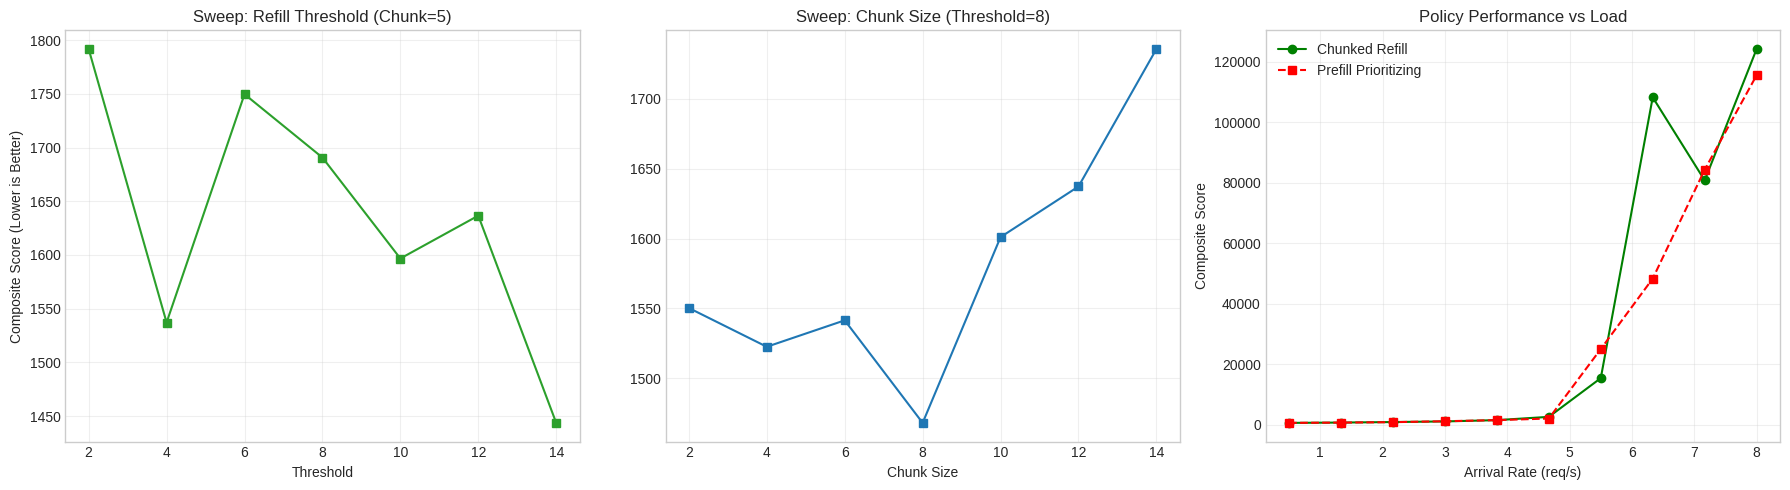

In [ ]:
# -------------------------------------------------
# Exp 8: Chunk analysis
# -------------------------------------------------
# --- 2. Parameter Sweep (Finding Optimal) ---

def run_parameter_sweeps():
    print("--- Running Parameter Sweeps for Chunked Refill ---")

    fixed_lambda = 4.0 # High load
    num_reqs = 3000

    # 2a. Sweep Threshold (Fixed chunk size)
    chunk_fixed = 5
    thresholds = [2, 4, 6, 8, 10, 12, 14]
    res_thresh = []

    for t in thresholds:
        p = DEFAULT_PARAMS.copy()
        p.update({'policy': 'chunked_refill', 'lambda': fixed_lambda, 'chunk_size': chunk_fixed, 'refill_threshold': t})
        reqs = run_simulation(num_reqs, p, warmup=500)
        df = get_metrics_df(reqs)
        if not df.empty:
            score = df['TTFT'].mean() + 10 * df['TBT'].mean()
            res_thresh.append({'Parameter_Value': t, 'Composite_Score': score})

    # 2b. Sweep Chunk Size (Fixed threshold)
    thresh_fixed = 8
    chunks = [2, 4, 6, 8, 10, 12, 14]
    res_chunk = []

    for c in chunks:
        p = DEFAULT_PARAMS.copy()
        p.update({'policy': 'chunked_refill', 'lambda': fixed_lambda, 'chunk_size': c, 'refill_threshold': thresh_fixed})
        reqs = run_simulation(num_reqs, p, warmup=500)
        df = get_metrics_df(reqs)
        if not df.empty:
            score = df['TTFT'].mean() + 10 * df['TBT'].mean()
            res_chunk.append({'Parameter_Value': c, 'Composite_Score': score})

    return pd.DataFrame(res_thresh), pd.DataFrame(res_chunk)

# --- 3. Policy Comparison ---

def run_policy_comparison_sweep():
    print("--- Running Policy Comparison Sweep ---")

    lambdas = np.linspace(0.5, 8.0, 10)
    res_comp = []

    # Optimal params from theory/previous sweep (you can adjust these based on the first plot results)
    opt_chunk = 4
    opt_thresh = 8

    for lam in lambdas:
        # Chunked Refill
        p1 = DEFAULT_PARAMS.copy()
        p1.update({'policy': 'chunked_refill', 'lambda': lam, 'chunk_size': opt_chunk, 'refill_threshold': opt_thresh})
        r1 = run_simulation(3000, p1, warmup=500)
        df1 = get_metrics_df(r1)
        score1 = df1['TTFT'].mean() + 10 * df1['TBT'].mean() if not df1.empty else float('nan')

        # Prefill Prioritizing (Baseline)
        p2 = DEFAULT_PARAMS.copy()
        p2.update({'policy': 'prefill_prioritizing', 'lambda': lam})
        r2 = run_simulation(3000, p2, warmup=500)
        df2 = get_metrics_df(r2)
        score2 = df2['TTFT'].mean() + 10 * df2['TBT'].mean() if not df2.empty else float('nan')

        res_comp.append({
            'Lambda': lam,
            'Chunked_Refill': score1,
            'Prefill_Prioritizing': score2
        })

    return pd.DataFrame(res_comp)

# --- Main Execution ---
if __name__ == "__main__":
    # 1. Run Sweeps
    df_thresh, df_chunk = run_parameter_sweeps()

    # 2. Run Comparison
    df_comp = run_policy_comparison_sweep()

    # 3. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Threshold Sweep
    if not df_thresh.empty:
        axes[0].plot(df_thresh['Parameter_Value'], df_thresh['Composite_Score'], 's-', color='tab:green')
        axes[0].set_title(f'Sweep: Refill Threshold (Chunk=5)')
        axes[0].set_xlabel('Threshold')
        axes[0].set_ylabel('Composite Score (Lower is Better)')
        axes[0].grid(True, alpha=0.3)

    # Plot 2: Chunk Size Sweep
    if not df_chunk.empty:
        axes[1].plot(df_chunk['Parameter_Value'], df_chunk['Composite_Score'], 's-', color='tab:blue')
        axes[1].set_title(f'Sweep: Chunk Size (Threshold=8)')
        axes[1].set_xlabel('Chunk Size')
        axes[1].grid(True, alpha=0.3)

    # Plot 3: Policy Comparison
    if not df_comp.empty:
        axes[2].plot(df_comp['Lambda'], df_comp['Chunked_Refill'], 'g-o', label='Chunked Refill')
        axes[2].plot(df_comp['Lambda'], df_comp['Prefill_Prioritizing'], 'r--s', label='Prefill Prioritizing')
        axes[2].set_title('Policy Performance vs Load')
        axes[2].set_xlabel('Arrival Rate (req/s)')
        axes[2].set_ylabel('Composite Score')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('data/comparison_sweeps.png')
    plt.show()

--- Starting Sensitivity Analysis (Fast Mode) ---

[1/2] Sweeping Prompt Length (L)...
  > Running Policy: prefill_prioritizing...
  > Running Policy: decode_prioritizing...
  > Running Policy: chunked_refill...

[2/2] Sweeping Output Budget (B)...
  > Running Policy: prefill_prioritizing...
  > Running Policy: decode_prioritizing...
  > Running Policy: chunked_refill...

Generating Plots...


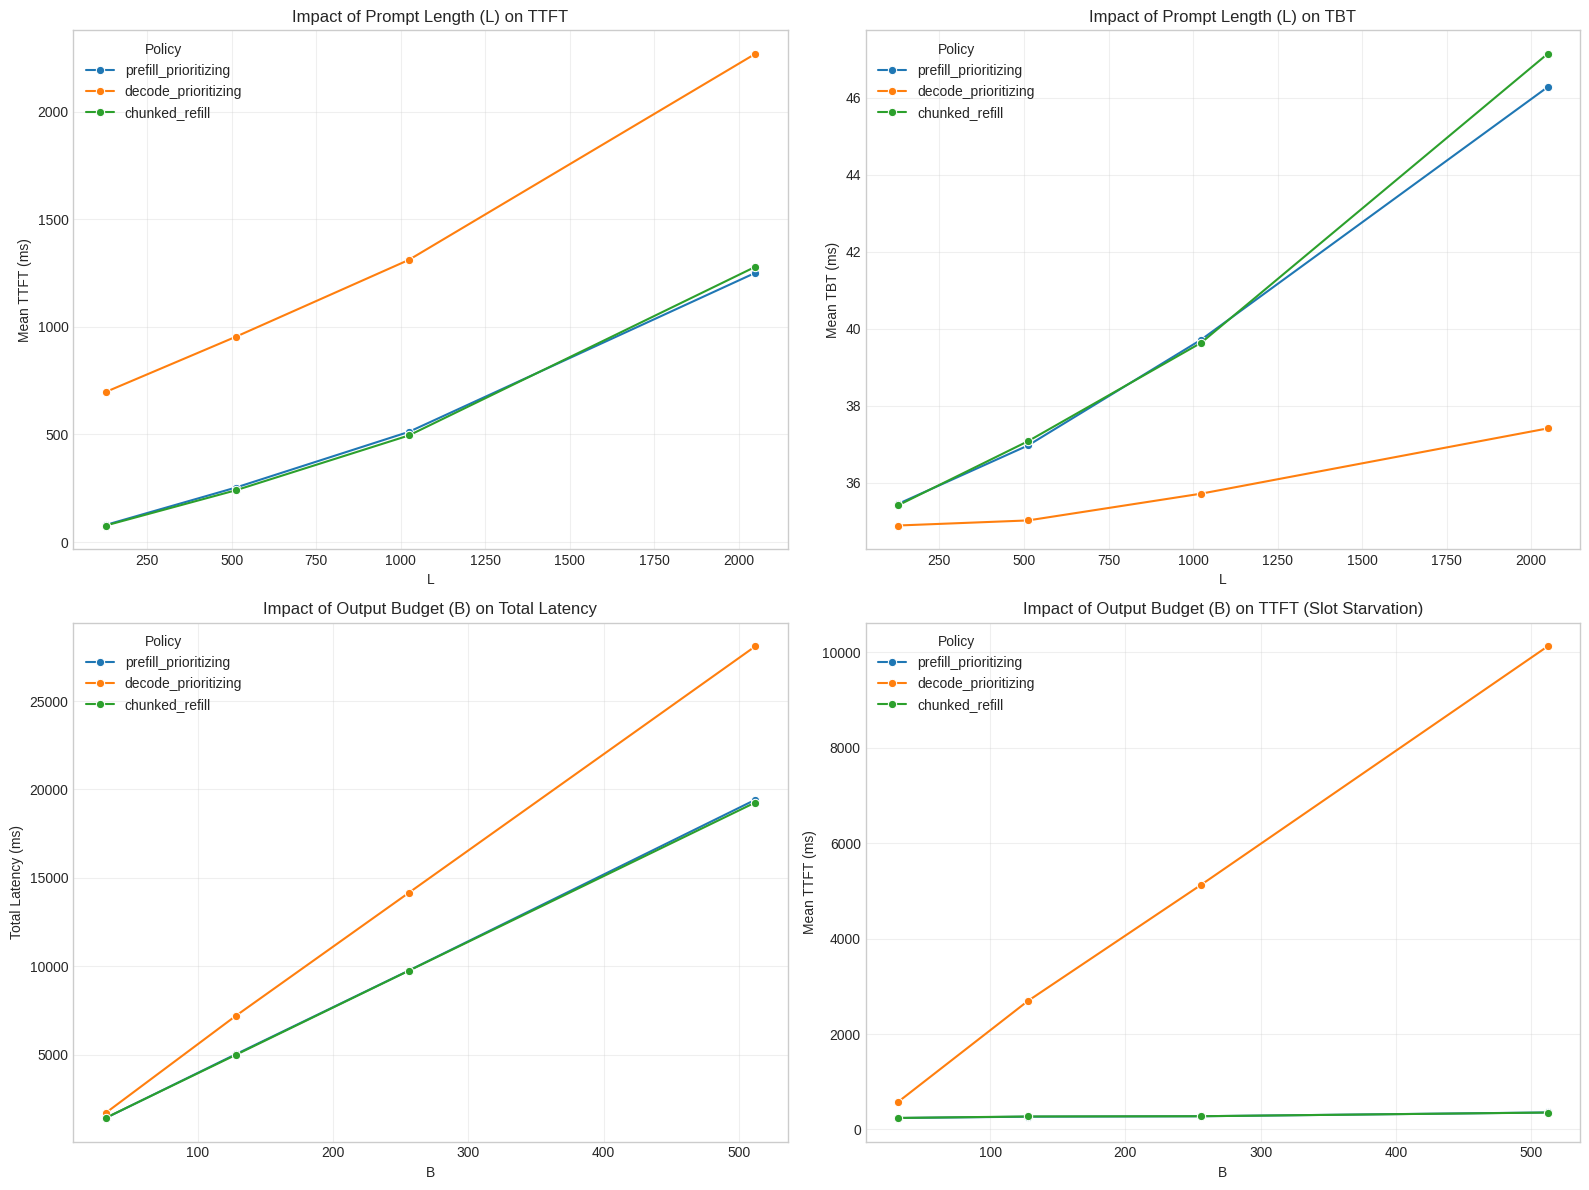

In [ ]:
# -------------------------------------------------
# Exp 9: workload sensitivity analysis
# -------------------------------------------------
def run_workload_sensitivity_analysis_fast():
    print("--- Starting Sensitivity Analysis (Fast Mode) ---")

    # 1. Comparison Setup
    # Ensure 'chunked_refill' params are tuned (e.g. Threshold=5, Chunk=10) from your previous step
    policies = ['prefill_prioritizing', 'decode_prioritizing', 'chunked_refill']

    # Use 2000 for plotting trends (saving 10,000 for the final single run)
    num_requests_viz = 2000
    warmup_viz = 500
    fixed_lambda = 0.5  # Moderate load to see differences clearly

    # ---------------------------------------------------------
    # Experiment A: Impact of Prompt Length (L)
    # ---------------------------------------------------------
    print("\n[1/2] Sweeping Prompt Length (L)...")
    L_values = [128, 512, 1024, 2048] # Reduced steps for speed
    fixed_B = 50
    results_L = []

    for pol in policies:
        print(f"  > Running Policy: {pol}...")
        for L in L_values:
            params = DEFAULT_PARAMS.copy()
            params.update({
                'policy': pol,
                'lambda': fixed_lambda,
                'fixed_L': L,
                'fixed_B': fixed_B,
                # Chunked Refill Specifics (Use your optimal values here)
                'refill_threshold': 5,
                'chunk_size': 10
            })

            # Run Simulation
            reqs = run_simulation(num_requests_viz, params, warmup=warmup_viz)
            df = get_metrics_df(reqs)

            if not df.empty:
                # Calculate Throughput (Req/s)
                duration = (reqs[-1].completion_time - reqs[0].arrival_time)
                throughput = len(reqs) / duration if duration > 0 else 0

                results_L.append({
                    'Policy': pol,
                    'L': L,
                    'TTFT': df['TTFT'].mean(),
                    'TBT': df['TBT'].mean(),
                    'Throughput': throughput
                })

    df_L = pd.DataFrame(results_L)

    # ---------------------------------------------------------
    # Experiment B: Impact of Output Budget (B)
    # ---------------------------------------------------------
    print("\n[2/2] Sweeping Output Budget (B)...")
    B_values = [32, 128, 256, 512] # Reduced steps for speed
    fixed_L = 512
    results_B = []

    for pol in policies:
        print(f"  > Running Policy: {pol}...")
        for B in B_values:
            params = DEFAULT_PARAMS.copy()
            params.update({
                'policy': pol,
                'lambda': fixed_lambda,
                'fixed_L': fixed_L,
                'fixed_B': B,
                'refill_threshold': 5,
                'chunk_size': 10
            })

            reqs = run_simulation(num_requests_viz, params, warmup=warmup_viz)
            df = get_metrics_df(reqs)

            if not df.empty:
                results_B.append({
                    'Policy': pol,
                    'B': B,
                    'TTFT': df['TTFT'].mean(),
                    'Latency': df['Total_Latency'].mean(),
                    'TBT': df['TBT'].mean()
                })

    df_B = pd.DataFrame(results_B)

    # ---------------------------------------------------------
    # Plotting
    # ---------------------------------------------------------
    print("\nGenerating Plots...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. L vs TTFT (Does a long prompt block new users?)
    sns.lineplot(data=df_L, x='L', y='TTFT', hue='Policy', marker='o', ax=axes[0,0])
    axes[0,0].set_title('Impact of Prompt Length (L) on TTFT')
    axes[0,0].set_ylabel('Mean TTFT (ms)')
    axes[0,0].grid(True, alpha=0.3)

    # 2. L vs TBT (Does a long prompt interrupt decoding?)
    sns.lineplot(data=df_L, x='L', y='TBT', hue='Policy', marker='o', ax=axes[0,1])
    axes[0,1].set_title('Impact of Prompt Length (L) on TBT')
    axes[0,1].set_ylabel('Mean TBT (ms)')
    axes[0,1].grid(True, alpha=0.3)


    # 3. B vs Latency (Total time in system)
    sns.lineplot(data=df_B, x='B', y='Latency', hue='Policy', marker='o', ax=axes[1,0])
    axes[1,0].set_title('Impact of Output Budget (B) on Total Latency')
    axes[1,0].set_ylabel('Total Latency (ms)')
    axes[1,0].grid(True, alpha=0.3)

    # 4. B vs TTFT (Does a long decode hog the slot?)
    sns.lineplot(data=df_B, x='B', y='TTFT', hue='Policy', marker='o', ax=axes[1,1])
    axes[1,1].set_title('Impact of Output Budget (B) on TTFT (Slot Starvation)')
    axes[1,1].set_ylabel('Mean TTFT (ms)')
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('data/budget_impact.png')
    plt.show()

if __name__ == "__main__":
    run_workload_sensitivity_analysis_fast()

--- Running Time-Series Metrics Experiment ---
  > Policy: prefill_prioritizing
  > Policy: decode_prioritizing
  > Policy: chunked_prefill


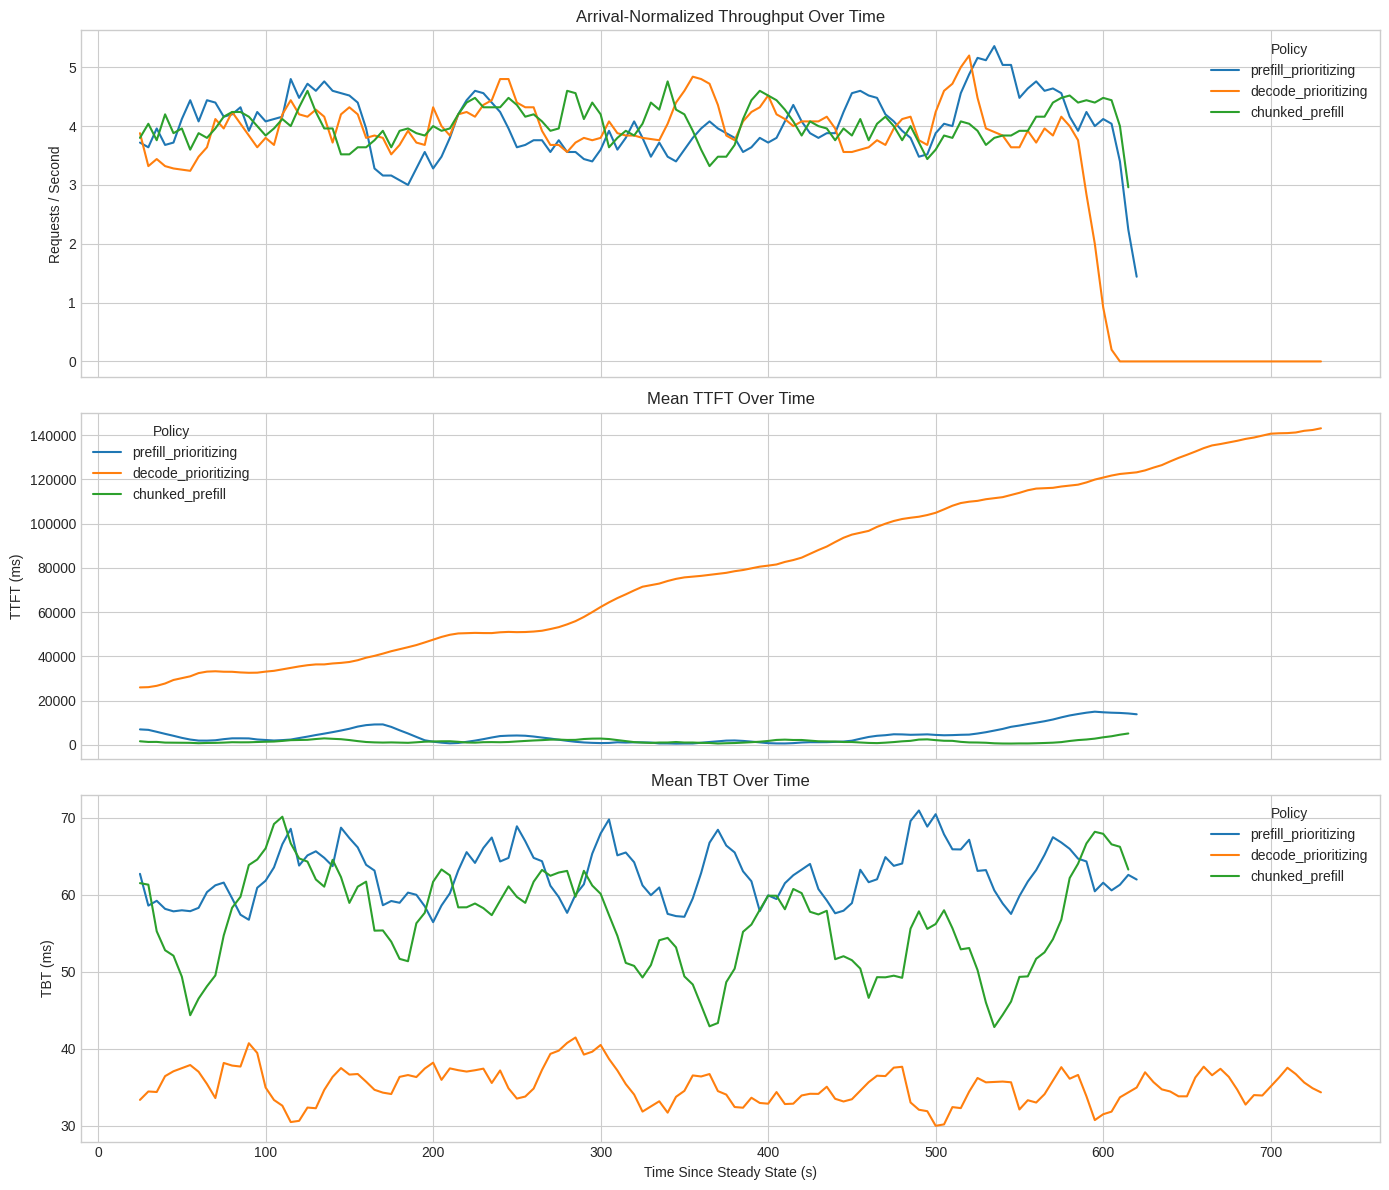

In [ ]:
# -------------------------------------------------
# Exp 10: time series analysis
# -------------------------------------------------
def compute_time_series_metrics(completed_requests, window_size=5.0):
    """
    Computes throughput, TTFT, and TBT over time using fixed-size windows.

    Args:
        completed_requests: list of completed Query objects
        window_size: time window in seconds

    Returns:
        DataFrame with columns:
        ['Time', 'Throughput', 'Mean_TTFT', 'Mean_TBT']
    """

    # Sort by completion time
    completed_requests = sorted(completed_requests, key=lambda r: r.completion_time)

    start_time = completed_requests[0].completion_time
    end_time = completed_requests[-1].completion_time

    time_bins = np.arange(start_time, end_time + window_size, window_size)

    records = []

    for t_start in time_bins[:-1]:
        t_end = t_start + window_size

        # Requests completed in this window
        window_reqs = [
            r for r in completed_requests
            if t_start <= r.completion_time < t_end
        ]

        if len(window_reqs) == 0:
            continue

        # Arrival-based throughput (avoids backlog artifacts)
        arrivals_in_window = [
            r for r in completed_requests
            if t_start <= r.arrival_time < t_end
        ]
        throughput = len(arrivals_in_window) / window_size

        # TTFT (ms)
        ttfts = [
            (r.first_token_time - r.arrival_time) * 1000
            for r in window_reqs
            if r.first_token_time is not None
        ]

        # TBT: mean per request (not per token)
        tbts = []
        for r in window_reqs:
            if len(r.decode_token_times) > 1:
                tbts.append(
                    np.mean(np.diff(r.decode_token_times)) * 1000
                )

        records.append({
            'Time': t_start - start_time,
            'Throughput': throughput,
            'Mean_TTFT': np.mean(ttfts) if ttfts else np.nan,
            'Mean_TBT': np.mean(tbts) if tbts else np.nan
        })

    df = pd.DataFrame(records)

    # Rolling smoothing to reduce estimator noise
    df[['Throughput', 'Mean_TTFT', 'Mean_TBT']] = (
        df[['Throughput', 'Mean_TTFT', 'Mean_TBT']]
        .rolling(window=5, min_periods=1)
        .mean()
    )

    # Drop early transient period (steady-state focus)
    df = df[df['Time'] > 20]

    return df


def run_time_series_experiment():
    print("--- Running Time-Series Metrics Experiment ---")

    policies = [
        'prefill_prioritizing',
        'decode_prioritizing',
        'chunked_prefill'
    ]

    num_requests = 3000
    warmup = 500
    window_size = 5.0  # seconds

    all_results = []

    for pol in policies:
        print(f"  > Policy: {pol}")

        params = DEFAULT_PARAMS.copy()
        params.update({
            'policy': pol,
            'lambda': 4.0,
            'fixed_L': 512,
            'fixed_B': 50,
            'chunk_size': 64
        })

        completed = run_simulation(num_requests, params, warmup=warmup)

        df_ts = compute_time_series_metrics(completed, window_size=window_size)
        df_ts['Policy'] = pol

        all_results.append(df_ts)

    return pd.concat(all_results, ignore_index=True)


def plot_time_series_metrics(df):
    plt.style.use('seaborn-v0_8-whitegrid')

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # Throughput
    sns.lineplot(
        data=df, x='Time', y='Throughput',
        hue='Policy', ax=axes[0]
    )
    axes[0].set_title('Arrival-Normalized Throughput Over Time')
    axes[0].set_ylabel('Requests / Second')

    # TTFT
    sns.lineplot(
        data=df, x='Time', y='Mean_TTFT',
        hue='Policy', ax=axes[1]
    )
    axes[1].set_title('Mean TTFT Over Time')
    axes[1].set_ylabel('TTFT (ms)')

    # TBT
    sns.lineplot(
        data=df, x='Time', y='Mean_TBT',
        hue='Policy', ax=axes[2]
    )
    axes[2].set_title('Mean TBT Over Time')
    axes[2].set_ylabel('TBT (ms)')
    axes[2].set_xlabel('Time Since Steady State (s)')

    plt.tight_layout()
    plt.savefig('data/time_series.png')
    plt.show()


if __name__ == "__main__":
    df_time_series = run_time_series_experiment()
    plot_time_series_metrics(df_time_series)


Validation

In [ ]:
import numpy as np

# Set a random seed for reproducible results (optional)
np.random.seed(42)

# --- 1. Simulation Classes (Minimal Implementation) ---

class Job:
    """Represents a single job/customer in the system."""
    def __init__(self, job_id, arrival_time, service_time):
        self.id = job_id
        self.arrival_time = arrival_time
        self.service_time = service_time
        self.service_start_time = None
        self.wait_time = 0.0
        self.system_time = 0.0

class Simulation_Environment:
    """
    Minimal simulation class for M/M/1 validation.
    The parameters are set to match the no-batching, no-setup-time case.
    """
    def __init__(self, server_count=1, batch_size=1, setup_time_c=0):
        self.server_count = server_count
        self.batch_size = batch_size
        self.setup_time_c = setup_time_c

        # State variables (simplified for a single server)
        self.server_available_time = 0.0
        self.finished_jobs = []

    def run(self, arrival_times, service_times):
        """Runs the simulation and collects metrics."""

        # 1. Create Job objects
        jobs = []
        for i in range(len(arrival_times)):
            jobs.append(Job(i, arrival_times[i], service_times[i]))

        # 2. Process Jobs
        for job in jobs:
            # Time when the server is ready (max of job arrival or server's previous finish time)
            queue_exit_time = max(job.arrival_time, self.server_available_time)

            # Since batch_size=1 and setup_time_c=0, the server starts service immediately
            # upon the job leaving the queue.
            job.service_start_time = queue_exit_time

            # Calculate metrics
            job.wait_time = job.service_start_time - job.arrival_time
            job_finish_time = job.service_start_time + job.service_time
            job.system_time = job_finish_time - job.arrival_time

            # Update the server's availability time for the next job
            self.server_available_time = job_finish_time

            self.finished_jobs.append(job)

        # 3. Calculate Simulation Metrics
        all_wait_times = np.array([j.wait_time for j in self.finished_jobs])
        all_system_times = np.array([j.system_time for j in self.finished_jobs])

        # NOTE: For Lq and L, we approximate using Little's Law (L = lambda * W)
        # as calculating time-averaged Lq/L is complex in a simple trace-driven simulation.

        return {
            'avg_wait_time': np.mean(all_wait_times),
            'avg_system_time': np.mean(all_system_times),
            # Set Lq/L to None, letting the validation script use Little's Law
            'avg_queue_length': None,
            'avg_system_length': None,
        }

# --- 2. Distribution Generation Functions ---

def generate_exponential_times(rate, num_samples):
    """Generates random samples from an exponential distribution.
    The rate is lambda or mu (events/time), so the scale is 1/rate (time/event).
    """
    # np.random.exponential takes the 'scale' parameter, which is 1/rate
    return np.random.exponential(scale=1/rate, size=num_samples)

def generate_poisson_arrival(rate, num_samples):
    """Generates the cumulative arrival time for each job (Poisson process)."""
    # Generate inter-arrival times (exponentially distributed)
    inter_arrival_times = generate_exponential_times(rate, num_samples)
    # The arrival time of the nth job is the sum of the first n inter-arrival times.
    return np.cumsum(inter_arrival_times)

def generate_exponential_service(rate, num_samples):
    """Generates exponential service times for each job."""
    return generate_exponential_times(rate, num_samples)

# --- 3. M/M/1 Queueing Theory Formulas ---

def calculate_mm1_theory(lambda_rate, mu_rate):
    """Calculates the theoretical performance metrics for an M/M/1 queue."""
    if lambda_rate >= mu_rate:
        return "System is unstable (lambda >= mu).", None, None, None, None

    rho = lambda_rate / mu_rate

    # Average Waiting Time in Queue (Wq)
    Wq = lambda_rate / (mu_rate * (mu_rate - lambda_rate))

    # Average Time in System (W)
    W = 1 / (mu_rate - lambda_rate)

    # Average Number in Queue (Lq) - Little's Law: Lq = lambda * Wq
    Lq = lambda_rate * Wq

    # Average Number in System (L) - Little's Law: L = lambda * W
    L = lambda_rate * W

    return rho, Wq, W, Lq, L

# --- 4. M/M/1 Validation Execution ---

# Configuration
NUM_JOBS = 100000  # Large number of jobs for statistical confidence
lambda_rate = 0.5  # Arrival rate (must be less than mu_rate for stability)
mu_rate = 1.0      # Service rate

# 1. Analytical Calculation
rho_theory, Wq_theory, W_theory, Lq_theory, L_theory = calculate_mm1_theory(lambda_rate, mu_rate)

print("--- M/M/1 Validation: Analytical Results ---")
print(f"Arrival Rate (lambda): {lambda_rate}")
print(f"Service Rate (mu): {mu_rate}")
print(f"Utilization (rho): {rho_theory:.4f}")
print(f"Theoretical Avg Waiting Time (Wq): {Wq_theory:.4f} (Time units)")
print(f"Theoretical Avg System Time (W): {W_theory:.4f} (Time units)")
print(f"Theoretical Avg Jobs in Queue (Lq): {Lq_theory:.4f} (Jobs)")
print(f"Theoretical Avg Jobs in System (L): {L_theory:.4f} (Jobs)\n")


# 2. Simulation Setup and Run

# Generate arrival and service times
arrival_times = generate_poisson_arrival(lambda_rate, NUM_JOBS)
service_times = generate_exponential_service(mu_rate, NUM_JOBS)

print("--- M/M/1 Validation: Simulation Run ---")

# Instantiate the Simulation Environment for M/M/1 case:
# 1 server, batch_size=1, setup_time_c=0
mm1_sim = Simulation_Environment(
    server_count=1,
    batch_size=1,
    setup_time_c=0,
)

# Run the simulation
sim_results = mm1_sim.run(arrival_times, service_times)

# 3. Comparison and Validation

# Extract results from the simulation output
Wq_sim = sim_results.get('avg_wait_time')
W_sim = sim_results.get('avg_system_time')
Lq_sim_approx = lambda_rate * Wq_sim  # Apply Little's Law
L_sim_approx = lambda_rate * W_sim    # Apply Little's Law


print(f"\nSimulated Avg Waiting Time (Wq_sim): {Wq_sim:.4f}")
print(f"Simulated Avg System Time (W_sim): {W_sim:.4f}")
print(f"Simulated Avg Jobs in Queue (Lq_sim): {Lq_sim_approx:.4f}")
print(f"Simulated Avg Jobs in System (L_sim): {L_sim_approx:.4f}\n")


# Calculate the percentage error
def percentage_error(theory, simulation):
    if theory == 0:
        return np.nan
    return abs(simulation - theory) / theory * 100

print("--- M/M/1 Validation: Error Check (Should be < 5%) ---")
print(f"Wq Error: {percentage_error(Wq_theory, Wq_sim):.2f}%")
print(f"W Error: {percentage_error(W_theory, W_sim):.2f}%")
print(f"Lq Error: {percentage_error(Lq_theory, Lq_sim_approx):.2f}%")
print(f"L Error: {percentage_error(L_theory, L_sim_approx):.2f}%")

--- M/M/1 Validation: Analytical Results ---
Arrival Rate (lambda): 0.5
Service Rate (mu): 1.0
Utilization (rho): 0.5000
Theoretical Avg Waiting Time (Wq): 1.0000 (Time units)
Theoretical Avg System Time (W): 2.0000 (Time units)
Theoretical Avg Jobs in Queue (Lq): 0.5000 (Jobs)
Theoretical Avg Jobs in System (L): 1.0000 (Jobs)

--- M/M/1 Validation: Simulation Run ---

Simulated Avg Waiting Time (Wq_sim): 1.0082
Simulated Avg System Time (W_sim): 2.0128
Simulated Avg Jobs in Queue (Lq_sim): 0.5041
Simulated Avg Jobs in System (L_sim): 1.0064

--- M/M/1 Validation: Error Check (Should be < 5%) ---
Wq Error: 0.82%
W Error: 0.64%
Lq Error: 0.82%
L Error: 0.64%


Code for p95, TBFT, and TBT against Lambda Plots

In [ ]:
def sweep_lambda_metrics(lambdas, base_params, num_requests=20000, warmup=2000):
    rows = []
    for lam in lambdas:
        params = base_params.copy()
        params["lambda"] = lam
        completed = run_simulation(num_requests=num_requests, params=params, warmup=warmup)
        df = get_metrics_df(completed)
        ttft_ms = 1000 * df["TTFT"]
        tbt_ms  = 1000 * df["TBT"]

        rows.append({
            "lambda": lam,
            "TTFT_mean_ms": ttft_ms.mean(),
            "TTFT_p95_ms":  ttft_ms.quantile(0.95),
            "TBT_mean_ms":  tbt_ms.mean(),
            "TBT_p95_ms":   tbt_ms.quantile(0.95),
        })

    return pd.DataFrame(rows).sort_values("lambda")


In [ ]:
lambdas = np.arange(0.5, 10.5, 0.5)
base_params = DEFAULT_PARAMS.copy()
base_params["policy"] = "prefill_prioritizing"
results = sweep_lambda_metrics(lambdas, base_params, num_requests=20000, warmup=2000)
results.head()

,lambda,TTFT_mean_ms,TTFT_p95_ms,TBT_mean_ms,TBT_p95_ms
0,0.5,212765.905454,5.060924e+05,37142.578650,55412.773463
1,1.0,247743.786404,6.082247e+05,40006.422924,63104.221758
2,1.5,294323.741190,7.729215e+05,42758.340565,71552.019623
3,2.0,348545.269628,9.344996e+05,45740.004362,78995.992473
4,2.5,410311.310490,1.092306e+06,49992.403428,88897.116653


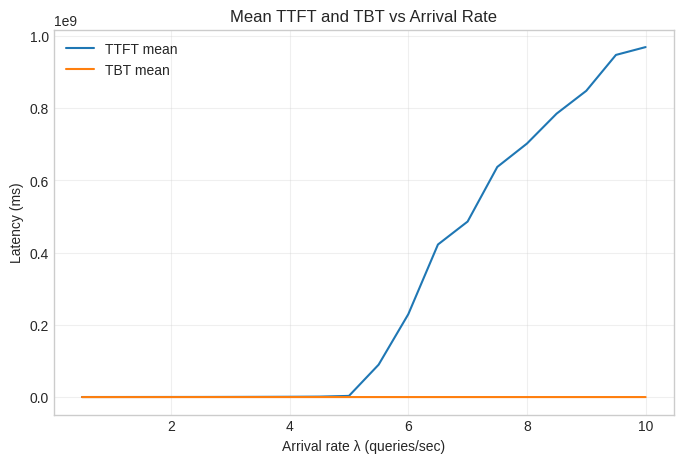

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results["lambda"], results["TTFT_mean_ms"], label="TTFT mean")
plt.plot(results["lambda"], results["TBT_mean_ms"], label="TBT mean")
plt.xlabel("Arrival rate λ (queries/sec)")
plt.ylabel("Latency (ms)")
plt.title("Mean TTFT and TBT vs Arrival Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('data/meanTTFT_TBT.png')
plt.show()

SLO Violation Rates

<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:95: SyntaxWarning: invalid escape sequence '\l'
<>:83: SyntaxWarning: invalid escape sequence '\l'
<>:95: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-2524815642.py:83: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel("Arrival Rate ($\lambda$)")
/tmp/ipython-input-2524815642.py:95: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel("Arrival Rate ($\lambda$)")


Running SLO Violation Analysis...
  Simulating Policy: prefill_prioritizing
  Simulating Policy: chunked_refill


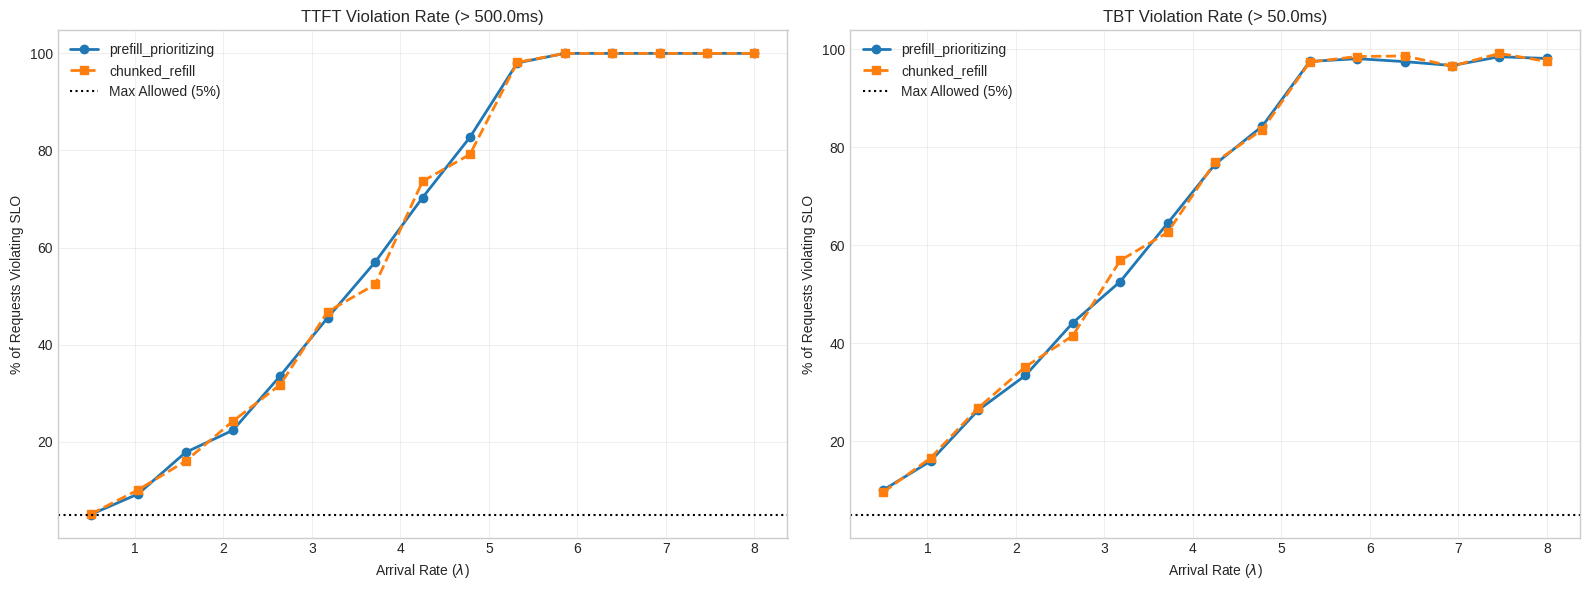

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections


SLO_TTFT_MS = 500.0  # Target: 95% of requests should be <= 500ms
SLO_TBT_MS = 50.0    # Target: 95% of requests should be <= 50ms

def get_slo_metrics(requests):
    """Calculates the % of requests that VIOLATED the SLO."""
    if not requests:
        return {'ttft_violation_rate': 0, 'tbt_violation_rate': 0}

    ttft_violations = 0
    tbt_violations = 0
    valid_tbt_count = 0

    for r in requests:
        if r.first_token_time is None: continue

        # Check TTFT
        ttft = (r.first_token_time - r.arrival_time) * 1000
        if ttft > SLO_TTFT_MS:
            ttft_violations += 1

        # Check TBT (average TBT for this request)
        if len(r.decode_token_times) > 1:
            avg_tbt = np.mean(np.diff(r.decode_token_times)) * 1000
            valid_tbt_count += 1
            if avg_tbt > SLO_TBT_MS:
                tbt_violations += 1

    # Calculate Rates (0.0 to 1.0)
    ttft_rate = ttft_violations / len(requests)
    tbt_rate = tbt_violations / valid_tbt_count if valid_tbt_count > 0 else 0

    return {
        'ttft_violation_rate': ttft_rate * 100, # Convert to %
        'tbt_violation_rate': tbt_rate * 100
    }

def run_slo_analysis():
    print("Running SLO Violation Analysis...")

    # Sweep Lambda from low to high
    lambda_values = np.linspace(0.5, 8.0, 15)
    policies = ['prefill_prioritizing', 'chunked_refill'] # Comparing baseline vs optimal

    results = {pol: {'lambda': [], 'ttft_bad': [], 'tbt_bad': []} for pol in policies}

    for pol in policies:
        print(f"  Simulating Policy: {pol}")
        for lam in lambda_values:
            params = DEFAULT_PARAMS.copy()
            params['lambda'] = lam
            params['policy'] = pol

            # Special setup for Chunked Refill (if not already in your default)
            if pol == 'chunked_refill':
                # We assume you added logic for this in 'get_new_admissions'
                # If not, this acts as a placeholder for your 'optimal' logic
                params['chunk_size'] = 10

            # Run Sim
            reqs = run_simulation(3000, params, warmup=500)
            metrics = get_slo_metrics(reqs)

            results[pol]['lambda'].append(lam)
            results[pol]['ttft_bad'].append(metrics['ttft_violation_rate'])
            results[pol]['tbt_bad'].append(metrics['tbt_violation_rate'])


    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: TTFT Violations
    for pol in policies:
        style = 'o-' if pol == 'prefill_prioritizing' else 's--'
        axes[0].plot(results[pol]['lambda'], results[pol]['ttft_bad'], style, linewidth=2, label=pol)

    axes[0].axhline(y=5.0, color='k', linestyle=':', label='Max Allowed (5%)')
    axes[0].set_title(f"TTFT Violation Rate (> {SLO_TTFT_MS}ms)")
    axes[0].set_xlabel("Arrival Rate ($\lambda$)")
    axes[0].set_ylabel("% of Requests Violating SLO")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: TBT Violations
    for pol in policies:
        style = 'o-' if pol == 'prefill_prioritizing' else 's--'
        axes[1].plot(results[pol]['lambda'], results[pol]['tbt_bad'], style, linewidth=2, label=pol)

    axes[1].axhline(y=5.0, color='k', linestyle=':', label='Max Allowed (5%)')
    axes[1].set_title(f"TBT Violation Rate (> {SLO_TBT_MS}ms)")
    axes[1].set_xlabel("Arrival Rate ($\lambda$)")
    axes[1].set_ylabel("% of Requests Violating SLO")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('data/slo_violation.png')
    plt.show()

# Run it
run_slo_analysis()

In [ ]:
#Downloading data folder
import shutil

shutil.make_archive(
    base_name="data",   # name of zip file (data.zip)
    format="zip",
    root_dir="data"     # folder you want to download
)


'/content/data.zip'

In [ ]:
from google.colab import files

files.download("data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>